In [1]:
import os
from pathlib import Path

repo_dir = Path('/content/libreyolo')
if repo_dir.exists():
    print('Removing existing repo directory to start clean...')
    !rm -rf /content/libreyolo

!git clone https://github.com/bencejdanko/libreyolo.git /content/libreyolo
%cd /content/libreyolo
!git fetch origin
!git checkout librefomo
!git status --short
!git branch --show-current


Cloning into '/content/libreyolo'...
remote: Enumerating objects: 13128, done.
remote: Counting objects: 100% (3480/3480), done.
remote: Compressing objects: 100% (784/784), done.
remote: Total 13128 (delta 3021), reused 2722 (delta 2696), pack-reused 9648 (from 2)
Receiving objects: 100% (13128/13128), 40.95 MiB | 16.90 MiB/s, done.
Resolving deltas: 100% (9619/9619), done.
/content/libreyolo
Branch 'librefomo' set up to track remote branch 'librefomo' from 'origin'.
Switched to a new branch 'librefomo'
librefomo


In [2]:
%cd /content/libreyolo
!python -m pip install -q --upgrade pip
!python -m pip install -q -e .
!python -m pip install -q matplotlib pillow opencv-python
import sys
print('Python version:', sys.version)
print('libreyolo installed from:')
!python -c 'import libreyolo; print(libreyolo.__file__)'


/content/libreyolo
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for libreyolo (pyproject.toml) ... done
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
libreyolo installed from:
/content/libreyolo/libreyolo/__init__.py


In [3]:
!wget https://cdn.openwear.ai/dog-no-augmentation.v1i.yolov8.zip

--2026-06-16 15:41:22--  https://cdn.openwear.ai/dog-no-augmentation.v1i.yolov8.zip
Resolving cdn.openwear.ai (cdn.openwear.ai)... 104.21.44.33, 172.67.194.161, 2606:4700:3034::6815:2c21, ...
Connecting to cdn.openwear.ai (cdn.openwear.ai)|104.21.44.33|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 103694292 (99M) [application/x-zip-compressed]
Saving to: ‘dog-no-augmentation.v1i.yolov8.zip’

dog-no-augmentation 100%[===================>]  98.89M  73.7MB/s    in 1.3s    

2026-06-16 15:41:24 (73.7 MB/s) - ‘dog-no-augmentation.v1i.yolov8.zip’ saved [103694292/103694292]



In [4]:
!rm -rf dog-no-augmentation.v1i.yolov8
!unzip -o dog-no-augmentation.v1i.yolov8.zip -d /content/dog-no-augmentation.v1i.yolov8

Archive:  dog-no-augmentation.v1i.yolov8.zip
 extracting: /content/dog-no-augmentation.v1i.yolov8/train/images/frame_0217_jpg.rf.dd3e7921e26d36d5f597b8829e8c4e1f.jpg  
 extracting: /content/dog-no-augmentation.v1i.yolov8/test/images/frame_0227_jpg.rf.758f6b66059d92e77abea6659686e714.jpg  
 extracting: /content/dog-no-augmentation.v1i.yolov8/train/images/frame_0365_jpg.rf.133161d87942148ceca46a28fd8db0e0.jpg  
 extracting: /content/dog-no-augmentation.v1i.yolov8/test/images/frame_0003_jpg.rf.983182557adcaff67e270e5b35c17aa1.jpg  
 extracting: /content/dog-no-augmentation.v1i.yolov8/train/images/frame_0057_jpg.rf.e25ecd6a2fa7cff60214fcaa2f5229e6.jpg  
 extracting: /content/dog-no-augmentation.v1i.yolov8/test/images/frame_0553_jpg.rf.3a8e47d872c819d914bc7f24f1cc7203.jpg  
 extracting: /content/dog-no-augmentation.v1i.yolov8/train/images/frame_0549_jpg.rf.90d84b2f6234034837dbc302c012b36a.jpg  
 extracting: /content/dog-no-augmentation.v1i.yolov8/test/images/frame_0063_jpg.rf.dda136ce26a004

In [ ]:
# place this in data.yaml:
"""
train: ./train/images
val: ./valid/images
test: ./test/images
"""

In [5]:
from pathlib import Path
import yaml

# Update this path to your dataset location in Colab.
data_yaml = Path('/content/dog-no-augmentation.v1i.yolov8/data.yaml')

print('Expected dataset YAML:', data_yaml)
print('Exists:', data_yaml.exists())

if data_yaml.exists():
    with open(data_yaml, 'r') as f:
        data_cfg = yaml.safe_load(f)
    print('Dataset config:')
    print(data_cfg)
    root = Path(data_cfg.get('root', '/content/dog-no-augmentation.v1i.yolov8'))
    print('Resolved root:', root)
    train_path = Path(data_cfg.get('train', 'images/train'))
    val_path = Path(data_cfg.get('val', 'images/val'))
    print('Train images sample:')
    !find {root / train_path} -maxdepth 2 -type f | head -n 5
    print('Val images sample:')
    !find {root / val_path} -maxdepth 2 -type f | head -n 5
else:
    print('Please upload your dataset to /content/dataset and update data_yaml path.')


Expected dataset YAML: /content/dog-no-augmentation.v1i.yolov8/data.yaml
Exists: True
Dataset config:
{'train': './train/images', 'val': './valid/images', 'test': './test/images', 'nc': 1, 'names': ['0'], 'roboflow': {'workspace': 'bences-workspace-zmeqo', 'project': 'dog-no-augmentation-qnlok', 'version': 1, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/bences-workspace-zmeqo/dog-no-augmentation-qnlok/dataset/1'}}
Resolved root: /content/dog-no-augmentation.v1i.yolov8
Train images sample:
/content/dog-no-augmentation.v1i.yolov8/train/images/frame_0409_jpg.rf.3dbc81c091fbff4ca23e586a33b19fca.jpg
/content/dog-no-augmentation.v1i.yolov8/train/images/frame_0467_jpg.rf.254b8bc90a58052a8fdd30792ff4e9f3.jpg
/content/dog-no-augmentation.v1i.yolov8/train/images/frame_0257_jpg.rf.fd40ea592420fa4f38f359a4bbef7934.jpg
/content/dog-no-augmentation.v1i.yolov8/train/images/frame_0015_jpg.rf.a63fd2b8591533f50edc0aeea01a1f20.jpg
/content/dog-no-augmentation.v1i.yolov8/train/images/fram

In [6]:
from pathlib import Path
from libreyolo import LibreFOMO

model_size = 'm'  # choose s, m, or l
nb_classes = 1  # set this to your dataset's number of classes
output_dir = Path('/content/librefomo_runs')
output_dir.mkdir(parents=True, exist_ok=True)

train_kwargs = dict(
    data=str(data_yaml),
    epochs=10,
    batch=8,
    workers=2,
    device='0',
    output_dir=str(output_dir),
    allow_download_scripts=False,
    exist_ok=True,
    allow_experimental=True,
    imgsz=96 if model_size == 's' else 192 if model_size == 'm' else 224,
    seed=0,
)

print('LibreFOMO variant:', model_size)
print('Dataset YAML:', data_yaml)
print('Output dir:', output_dir)
print('Training kwargs:')
print(train_kwargs)


LibreFOMO variant: m
Dataset YAML: /content/dog-no-augmentation.v1i.yolov8/data.yaml
Output dir: /content/librefomo_runs
Training kwargs:
{'data': '/content/dog-no-augmentation.v1i.yolov8/data.yaml', 'epochs': 10, 'batch': 8, 'workers': 2, 'device': '0', 'output_dir': '/content/librefomo_runs', 'allow_download_scripts': False, 'exist_ok': True, 'allow_experimental': True, 'imgsz': 192, 'seed': 0}


In [7]:
# Random weight training initialization

from libreyolo import LibreFOMO
from libreyolo.utils.logging import setup_logging

model = LibreFOMO(model_path=None, size=model_size, nb_classes=nb_classes, device='0')
print('Constructed LibreFOMO model:', model)

setup_logging(verbose=True)

result = model.train(**train_kwargs)
print('Training result:')
print(result)

print('Saved checkpoints in:')
!find {output_dir} -maxdepth 2 -type f | sort


/content/libreyolo/libreyolo/training/trainer.py:89: UserWarning: Unknown training config keys (ignored): ['output_dir']
  self.config = self._config_class().from_kwargs(**kwargs)
2026-06-16 15:41:59 | INFO     | Using device: cuda:0
2026-06-16 15:41:59 | INFO     | Setting up training...
2026-06-16 15:42:00 | INFO     | FOMOLoss rebuilt with resolved dataset nc=1
2026-06-16 15:42:00 | INFO     | FOMO training dataset: 242 images
2026-06-16 15:42:00 | INFO     | Grid size: 24×24 (imgsz=192, downsample=8)
2026-06-16 15:42:00 | INFO     | Iterations per epoch: 31 (batch_per_rank=8, world_size=1)
2026-06-16 15:42:00 | INFO     | Optimizer: adam
2026-06-16 15:42:00 | INFO     |   - pg0 (BN): 19 params
2026-06-16 15:42:00 | INFO     |   - pg1 (Conv, wd=0.0): 20 params
2026-06-16 15:42:00 | INFO     |   - pg2 (Bias): 20 params
2026-06-16 15:42:00 | INFO     | Saving to: runs/train/fomo_exp
2026-06-16 15:42:00 | INFO     | Starting training for 10 epochs
2026-06-16 15:42:00 | INFO     | Model

Constructed LibreFOMO model: <libreyolo.models.fomo.model.LibreFOMO object at 0x7c8d75072ae0>


2026-06-16 15:42:06 | INFO     | Epoch 1 - Average loss: 0.4267
2026-06-16 15:42:06 | INFO     | Running validation for epoch 1
2026-06-16 15:42:06 | INFO     | Loading 69 YOLO annotations from valid/labels...
2026-06-16 15:42:06 | INFO     | Loaded 69 YOLO annotations from valid/labels in 0.04s
2026-06-16 15:42:18 | INFO     | Validation - Point Metrics | P=0.0139 | R=0.0639 | F1=0.0228 | mAP@0.01=0.0122 | mAP_sweep=0.3604 | MLE=0.0071 | MAE=89.1014 | RMSE=89.8266
2026-06-16 15:42:18 | INFO     | Epoch 1 grid val | loss=0.6338 | grid_F1=0.4215 | grid_precision=0.3277 | grid_recall=0.5907 | MeanDist=0.701 | thresh=0.50 | nms_r=2.0 | TP=1006.0 FP=2064.0 FN=697.0 | LR=0.000293
2026-06-16 15:42:18 | INFO     | New best model saved - Epoch 1: metrics/grid_F1=0.4215
2026-06-16 15:42:18 | INFO     | Checkpoint saved: runs/train/fomo_exp/weights/last.pt
2026-06-16 15:42:23 | INFO     | Epoch 2 - Average loss: 0.2578
2026-06-16 15:42:23 | INFO     | Running validation for epoch 2
2026-06-16 15


----------------------------------------------------------------
LibreFOMO weights are hosted externally at huggingface.co/fomo-edge-ai/FOMO
under cc-by-nc-4.0.
They are treated as externally hosted, ImageNet-derived weights and
are not redistributed by LibreYOLO. By downloading them you accept
the Hugging Face repository license terms.
----------------------------------------------------------------

Training result:
{'final_loss': 0.10130583735242966, 'epoch_losses': [0.4266644360557679, 0.25779722438704583, 0.1960869320938664, 0.15842234992211865, 0.13575277838014788, 0.12187487848343388, 0.11127975486939953, 0.1059983384705359, 0.10289254808618177, 0.10130583735242966], 'epoch_lrs': [{'group0': 0.0002930255535720594, 'group1': 0.0002930255535720594, 'group2': 0.0002930255535720594}, {'group0': 0.00027278492169842996, 'group1': 0.00027278492169842996, 'group2': 0.00027278492169842996}, {'group0': 0.00024125939845167743, 'group1': 0.00024125939845167743, 'group2': 0.0002412593984516

Predicting on /content/dog-no-augmentation.v1i.yolov8/valid/images/frame_0005_jpg.rf.c62d6d788312106b15176e3fedf27d94.jpg


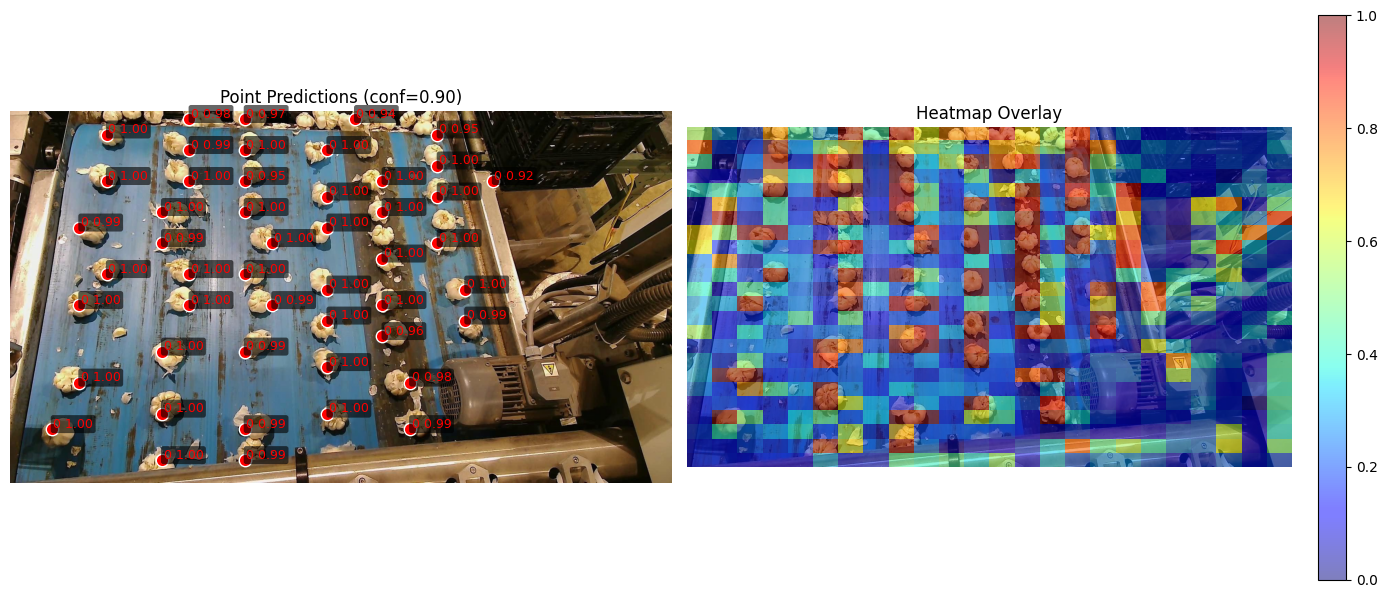

Predicting on /content/dog-no-augmentation.v1i.yolov8/valid/images/frame_0009_jpg.rf.02caf9ace1a55445d006e688aa0e715b.jpg


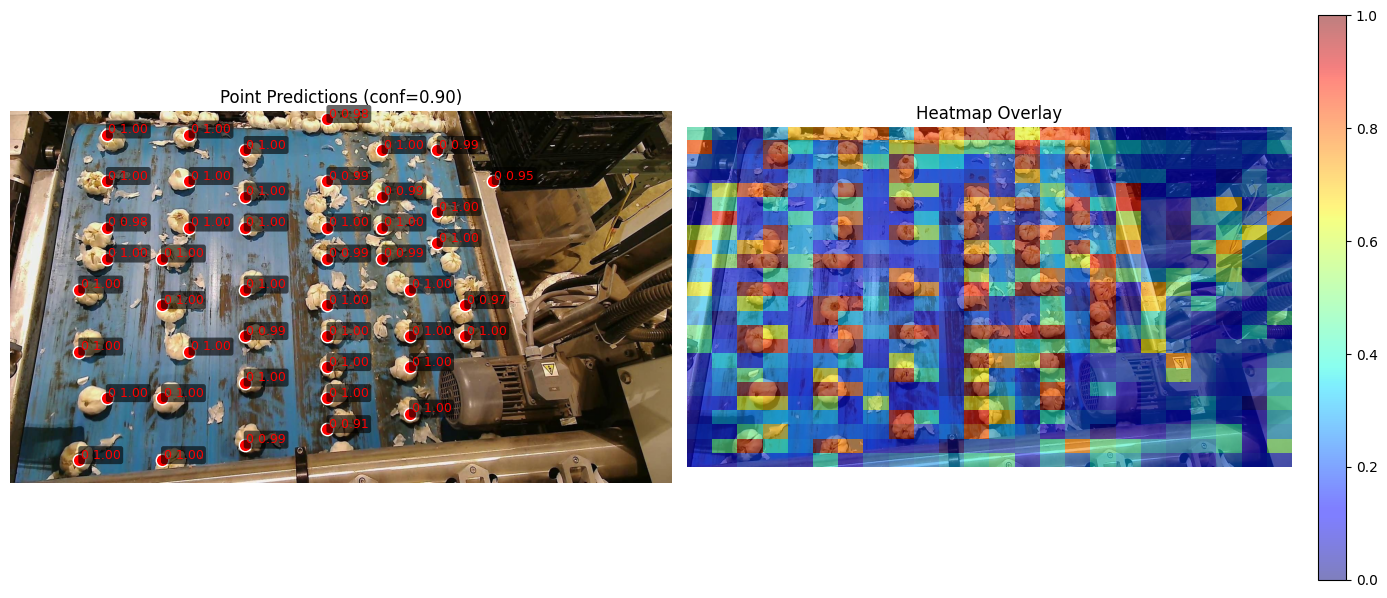

Predicting on /content/dog-no-augmentation.v1i.yolov8/valid/images/frame_0011_jpg.rf.94b188528a0866cb50a76ad16262b3d3.jpg


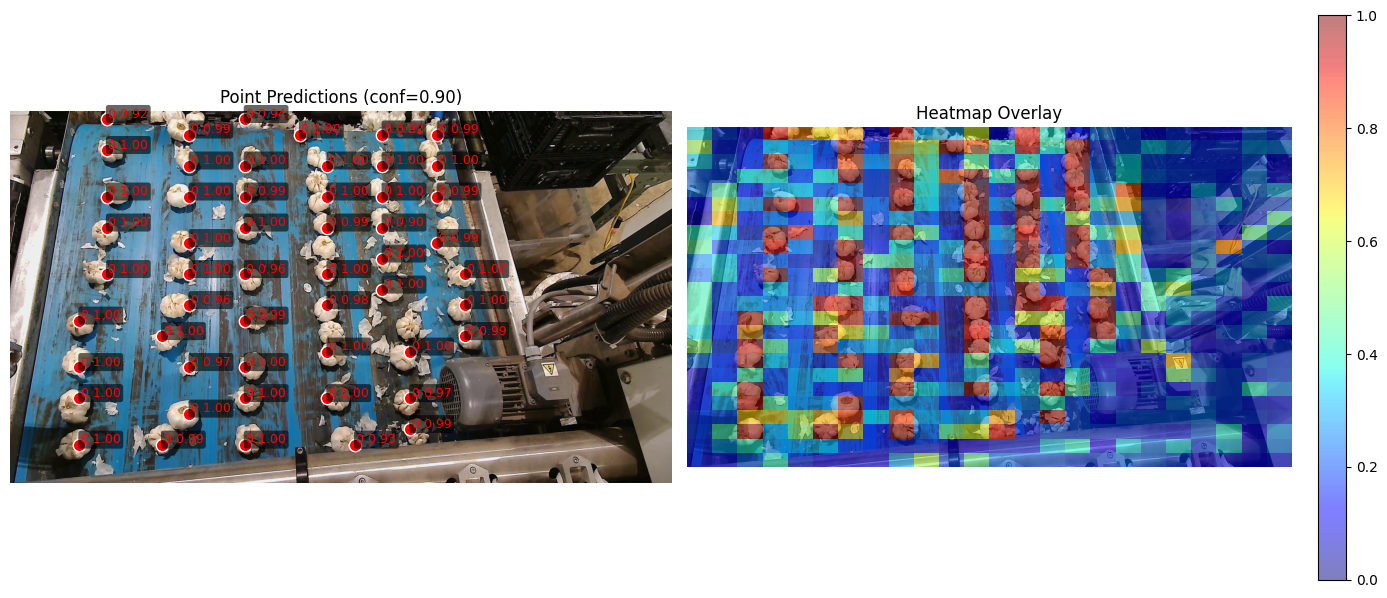

In [14]:
conf_thres = 0.9

import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

sample_dir = Path('/content/dog-no-augmentation.v1i.yolov8/valid/images')
if sample_dir.exists():
    sample_files = sorted(sample_dir.glob('*.*'))[:3]
    if sample_files:
        for path in sample_files:
            print('Predicting on', path)

            result = model(str(path), save=False, conf=conf_thres)

            imgsz = model._get_input_size()
            tensor, original_img, original_size, ratio = model._preprocess(str(path), input_size=imgsz)

            with torch.no_grad():
                logits = model.model(tensor.to(model.device))
                probs = F.softmax(logits, dim=1)

            heatmap = probs[0, 1:].max(dim=0)[0].cpu().numpy()

            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            orig_w, orig_h = original_size

            axes[0].imshow(original_img)
            if result.points is not None and len(result.points) > 0:
                pts = result.points.cpu().numpy()
                pts_xy = pts.xy
                pts_conf = pts.conf
                pts_cls = pts.cls
                axes[0].scatter(pts_xy[:, 0], pts_xy[:, 1], color='red', edgecolors='white', s=80, label='Detections')
                for (x, y), conf, cls_id in zip(pts_xy, pts_conf, pts_cls):
                    name = model.names.get(int(cls_id), f"class {int(cls_id)}")
                    axes[0].text(x + 5, y - 5, f"{name} {conf:.2f}", color='red', fontsize=9,
                                 bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))
            axes[0].set_title(f"Point Predictions (conf={conf_thres:.2f})")
            axes[0].axis('off')

            axes[1].imshow(original_img)
            im = axes[1].imshow(heatmap, extent=[0, orig_w, orig_h, 0], alpha=0.5, cmap='jet', vmin=0.0, vmax=1.0)
            fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
            axes[1].set_title("Heatmap Overlay")
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()
    else:
        print('No sample images found in', sample_dir)
else:
    print('Validation image directory does not exist:', sample_dir)


In [15]:
# Random weight training initialization

from libreyolo import LibreFOMO
from libreyolo.utils.logging import setup_logging

model = LibreFOMO(model_path="LibreFOMOm.pt", size=model_size, nb_classes=nb_classes, device='0')
print('Constructed LibreFOMO model:', model)

setup_logging(verbose=True)

result = model.train(**train_kwargs)
print('Training result:')
print(result)

print('Saved checkpoints in:')
!find {output_dir} -maxdepth 2 -type f | sort


2026-06-16 15:53:26 | INFO     | Model weights not found at LibreFOMOm.pt. Attempting download from https://huggingface.co/fomo-edge-ai/FOMO/resolve/main/weights/FOMOm.pt...
2026-06-16 15:53:26 | INFO     | Tip: Run `huggingface-cli login` or set HF_TOKEN for faster downloads.
2026-06-16 15:53:27 | INFO     | Downloading: 100% (0.1/0.1 MB)
2026-06-16 15:53:27 | INFO     | Download complete.
2026-06-16 15:53:27 | WARNING  | LibreYOLO checkpoint metadata is missing or incomplete for LibreFOMOm.pt: missing required key: libreyolo_version. Loading through the legacy compatibility path.
2026-06-16 15:53:27 | INFO     | Using device: cuda:0
2026-06-16 15:53:27 | INFO     | Setting up training...
2026-06-16 15:53:27 | INFO     | FOMOLoss rebuilt with resolved dataset nc=1
2026-06-16 15:53:27 | INFO     | FOMO training dataset: 242 images
2026-06-16 15:53:27 | INFO     | Grid size: 24×24 (imgsz=192, downsample=8)
2026-06-16 15:53:27 | INFO     | Iterations per epoch: 31 (batch_per_rank=8, worl

Constructed LibreFOMO model: <libreyolo.models.fomo.model.LibreFOMO object at 0x7c8b9819e540>


2026-06-16 15:53:34 | INFO     | Epoch 1 - Average loss: 0.4333
2026-06-16 15:53:34 | INFO     | Running validation for epoch 1
2026-06-16 15:53:34 | INFO     | Loading 69 YOLO annotations from valid/labels...
2026-06-16 15:53:34 | INFO     | Loaded 69 YOLO annotations from valid/labels in 0.04s
2026-06-16 15:53:46 | INFO     | Validation - Point Metrics | P=0.0316 | R=0.1471 | F1=0.0521 | mAP@0.01=0.0592 | mAP_sweep=0.7231 | MLE=0.0067 | MAE=90.2899 | RMSE=91.0058
2026-06-16 15:53:46 | INFO     | Epoch 1 grid val | loss=0.2253 | grid_F1=0.7765 | grid_precision=0.6841 | grid_recall=0.8978 | MeanDist=0.280 | thresh=0.90 | nms_r=1.0 | TP=1529.0 FP=706.0 FN=174.0 | LR=0.000293
2026-06-16 15:53:46 | INFO     | New best model saved - Epoch 1: metrics/grid_F1=0.7765
2026-06-16 15:53:46 | INFO     | Checkpoint saved: runs/train/fomo_exp/weights/last.pt
2026-06-16 15:53:51 | INFO     | Epoch 2 - Average loss: 0.1924
2026-06-16 15:53:51 | INFO     | Running validation for epoch 2
2026-06-16 15:

Training result:
{'final_loss': 0.06929655000567436, 'epoch_losses': [0.4332659273378311, 0.19237775860294218, 0.1362363599961804, 0.10640214936387155, 0.09030490729116625, 0.0808062661559351, 0.07613477471374697, 0.07156978968170381, 0.07010091408606499, 0.06929655000567436], 'epoch_lrs': [{'group0': 0.0002930255535720594, 'group1': 0.0002930255535720594, 'group2': 0.0002930255535720594}, {'group0': 0.00027278492169842996, 'group1': 0.00027278492169842996, 'group2': 0.00027278492169842996}, {'group0': 0.00024125939845167743, 'group1': 0.00024125939845167743, 'group2': 0.00024125939845167743}, {'group0': 0.00020153492169843, 'group1': 0.00020153492169843, 'group2': 0.00020153492169843}, {'group0': 0.00015749999999999998, 'group1': 0.00015749999999999998, 'group2': 0.00015749999999999998}, {'group0': 0.00011346507830156999, 'group1': 0.00011346507830156999, 'group2': 0.00011346507830156999}, {'group0': 7.374060154832258e-05, 'group1': 7.374060154832258e-05, 'group2': 7.374060154832258e-

Predicting on /content/dog-no-augmentation.v1i.yolov8/valid/images/frame_0005_jpg.rf.c62d6d788312106b15176e3fedf27d94.jpg


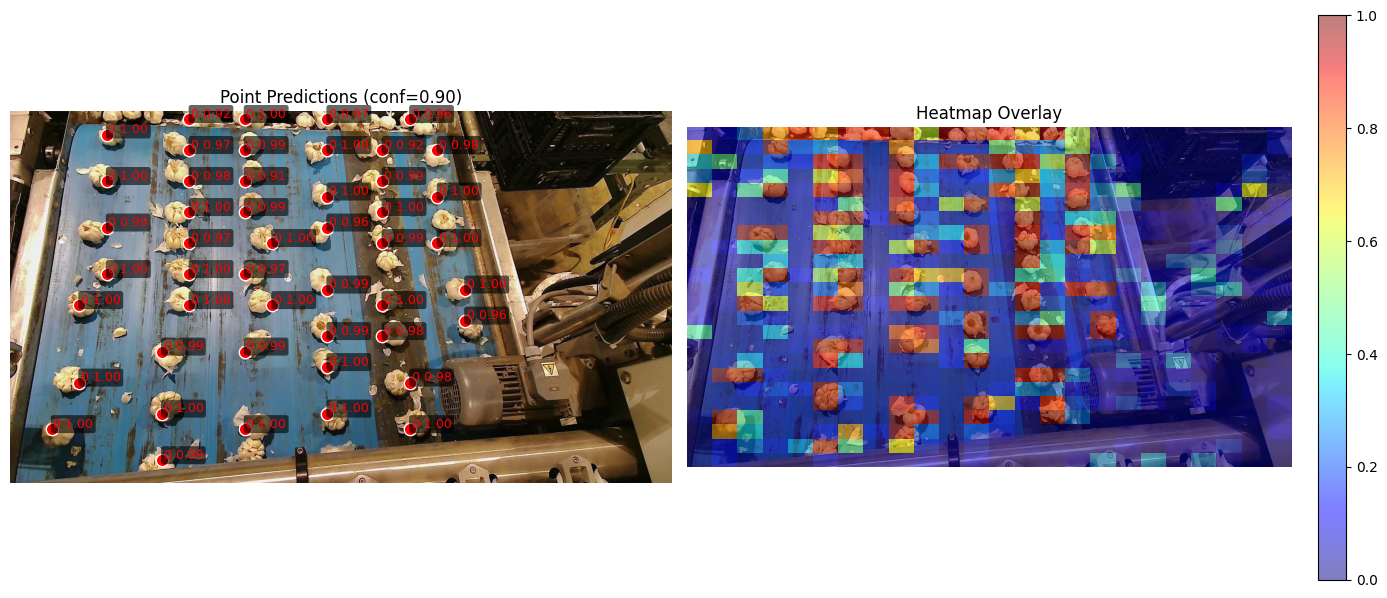

Predicting on /content/dog-no-augmentation.v1i.yolov8/valid/images/frame_0009_jpg.rf.02caf9ace1a55445d006e688aa0e715b.jpg


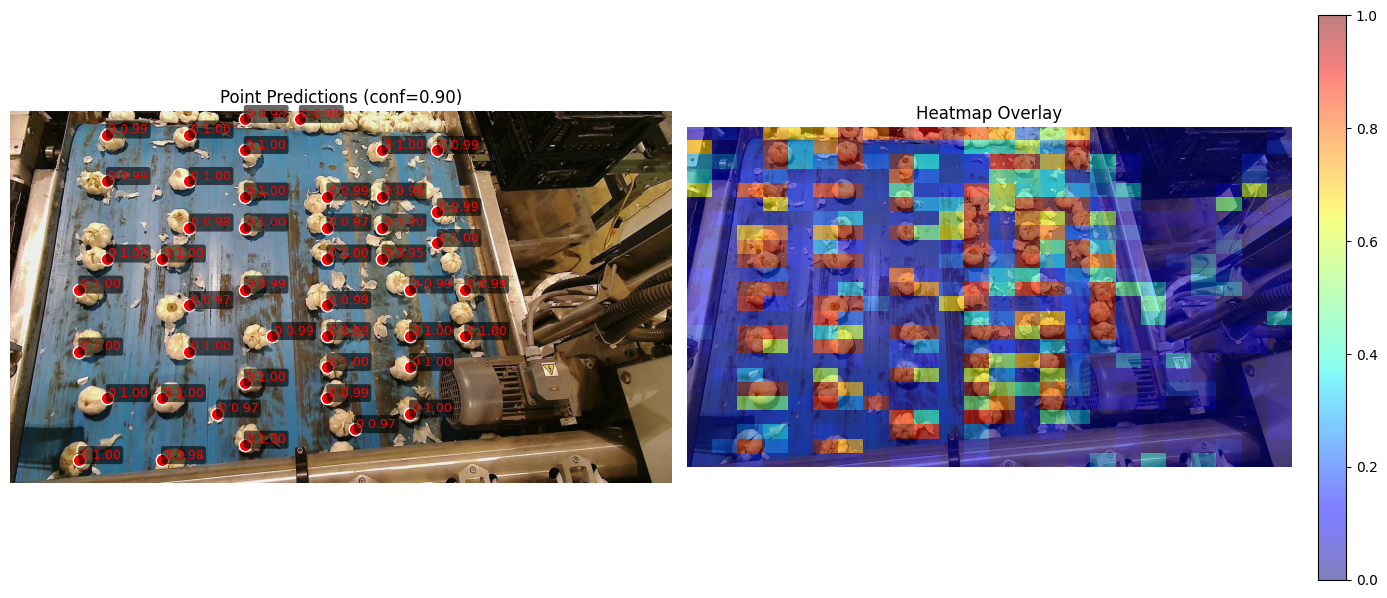

Predicting on /content/dog-no-augmentation.v1i.yolov8/valid/images/frame_0011_jpg.rf.94b188528a0866cb50a76ad16262b3d3.jpg


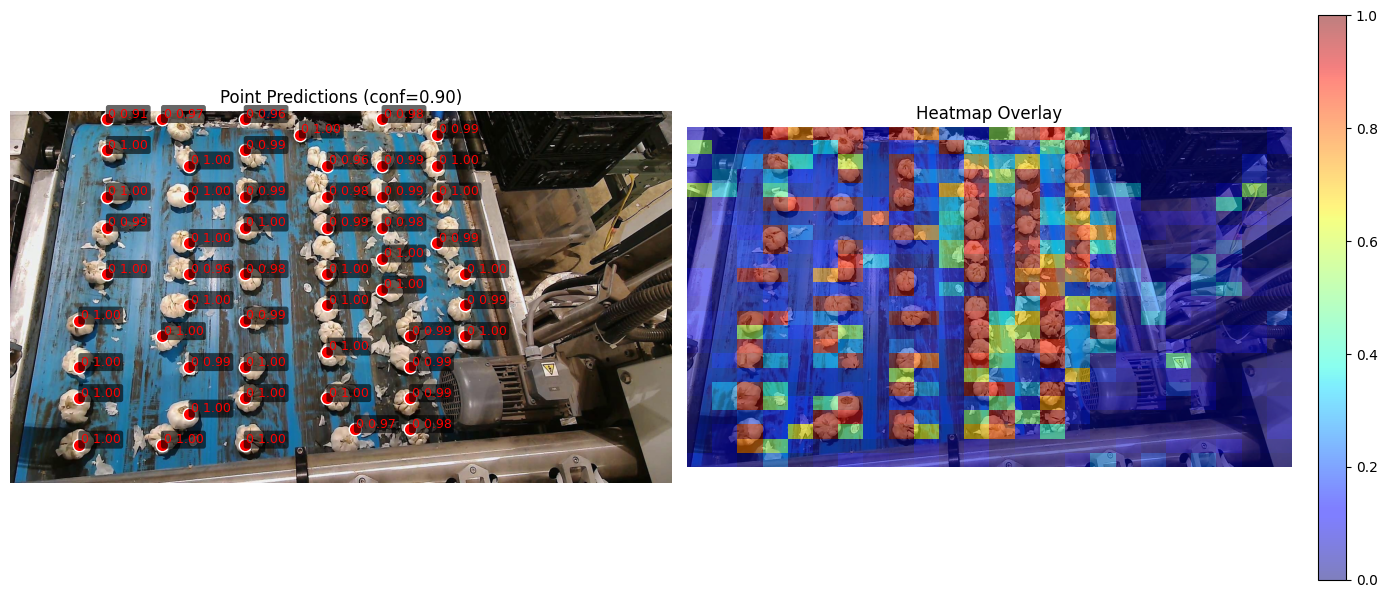

In [16]:
conf_thres = 0.9

import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

sample_dir = Path('/content/dog-no-augmentation.v1i.yolov8/valid/images')
if sample_dir.exists():
    sample_files = sorted(sample_dir.glob('*.*'))[:3]
    if sample_files:
        for path in sample_files:
            print('Predicting on', path)

            result = model(str(path), save=False, conf=conf_thres)

            imgsz = model._get_input_size()
            tensor, original_img, original_size, ratio = model._preprocess(str(path), input_size=imgsz)

            with torch.no_grad():
                logits = model.model(tensor.to(model.device))
                probs = F.softmax(logits, dim=1)

            heatmap = probs[0, 1:].max(dim=0)[0].cpu().numpy()

            fig, axes = plt.subplots(1, 2, figsize=(14, 6))
            orig_w, orig_h = original_size

            axes[0].imshow(original_img)
            if result.points is not None and len(result.points) > 0:
                pts = result.points.cpu().numpy()
                pts_xy = pts.xy
                pts_conf = pts.conf
                pts_cls = pts.cls
                axes[0].scatter(pts_xy[:, 0], pts_xy[:, 1], color='red', edgecolors='white', s=80, label='Detections')
                for (x, y), conf, cls_id in zip(pts_xy, pts_conf, pts_cls):
                    name = model.names.get(int(cls_id), f"class {int(cls_id)}")
                    axes[0].text(x + 5, y - 5, f"{name} {conf:.2f}", color='red', fontsize=9,
                                 bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2'))
            axes[0].set_title(f"Point Predictions (conf={conf_thres:.2f})")
            axes[0].axis('off')

            axes[1].imshow(original_img)
            im = axes[1].imshow(heatmap, extent=[0, orig_w, orig_h, 0], alpha=0.5, cmap='jet', vmin=0.0, vmax=1.0)
            fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
            axes[1].set_title("Heatmap Overlay")
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()
    else:
        print('No sample images found in', sample_dir)
else:
    print('Validation image directory does not exist:', sample_dir)
